In [20]:
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('gutenberg')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [21]:
# sense and sensibility 데이터 불러오기
raw_text = gutenberg.raw('austen-sense.txt')

In [22]:
# 1. 정규표현식을 이용한 토큰화 (영문 알파벳만 추출 및 소문자 변환)
tokenizer = RegexpTokenizer(r'[a-zA-Z]+')
tokens = tokenizer.tokenize(raw_text.lower())

# 2. Stopword(불용어) 제거
stop_words = set(stopwords.words('english'))
stopped_tokens = [word for word in tokens if word not in stop_words]

# 3. 품사 태깅 및 필터링
# NN(일반명사 단수), VB(동사 원형), VBZ(동사 3인칭 단수 현재), JJ(형용사)
tagged_tokens = pos_tag(stopped_tokens)
target_tags = ['NN', 'VB', 'VBZ', 'JJ']
final_tokens = [word for word, tag in tagged_tokens if tag in target_tags]

In [23]:
# 빈도 분포 계산
vocab = FreqDist(final_tokens)

# 빈도순 상위 30개 단어 추출
top30_words = vocab.most_common(30)
# 워드클라우드 생성을 위해 딕셔너리로 변환
top30_dict = dict(top30_words)

print("Top 30 단어 빈도수")
print(top30_words)

Top 30 단어 빈도수
[('elinor', 589), ('mrs', 470), ('marianne', 438), ('dashwood', 244), ('sister', 239), ('time', 239), ('mother', 201), ('nothing', 189), ('thing', 185), ('much', 183), ('willoughby', 179), ('good', 177), ('house', 161), ('john', 156), ('miss', 156), ('lucy', 151), ('mr', 150), ('little', 150), ('day', 150), ('great', 149), ('lady', 139), ('edward', 135), ('heart', 127), ('sure', 123), ('man', 121), ('room', 119), ('see', 115), ('give', 106), ('young', 103), ('last', 103)]


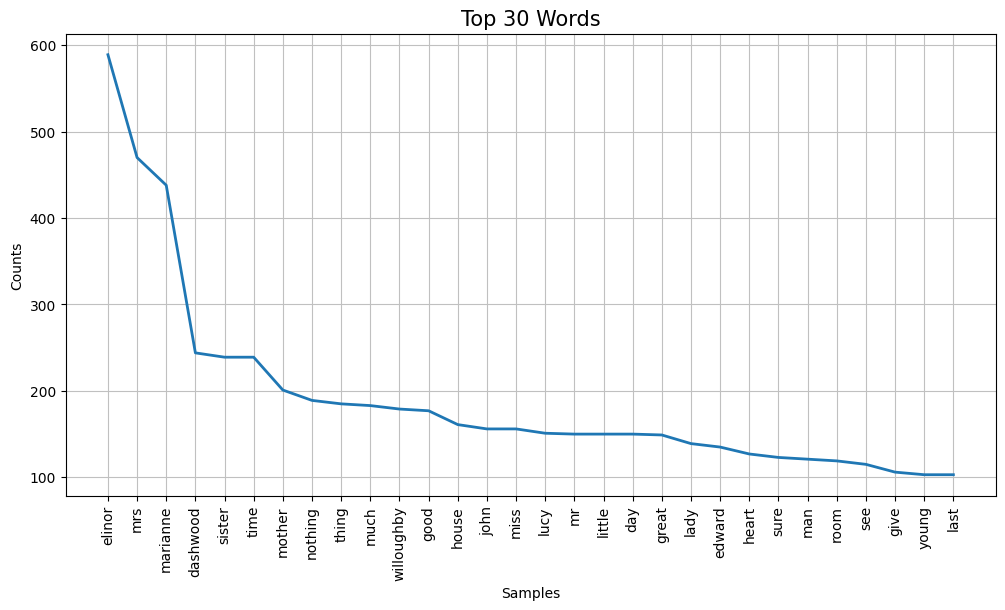

In [24]:
# 그래프 사이즈 설정 및 출력
plt.figure(figsize=(12, 6))
plt.title('Top 30 Words', fontsize=15)
plt.xticks(rotation=45)
vocab.plot(30)
plt.show()

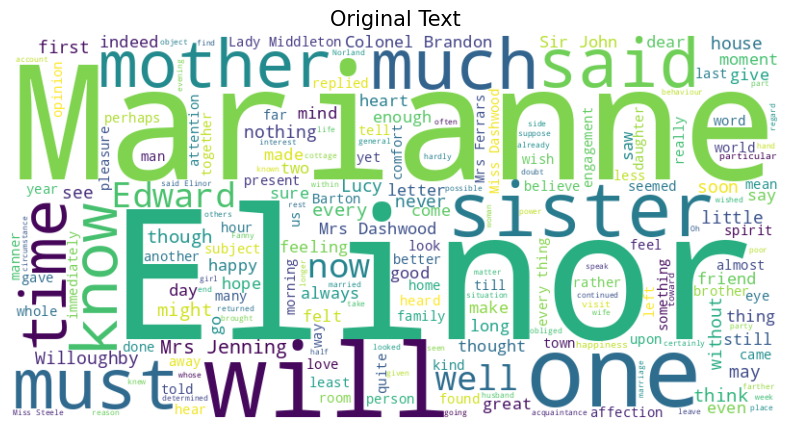

In [25]:
# 원문 텍스트를 기반으로 워드 클라우드 생성
wc_raw = WordCloud(width=800, height=400, 
                   background_color='white', 
                   colormap='viridis').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_raw, interpolation='bilinear')
plt.title('Original Text', fontsize=15)
plt.axis('off')
plt.show()

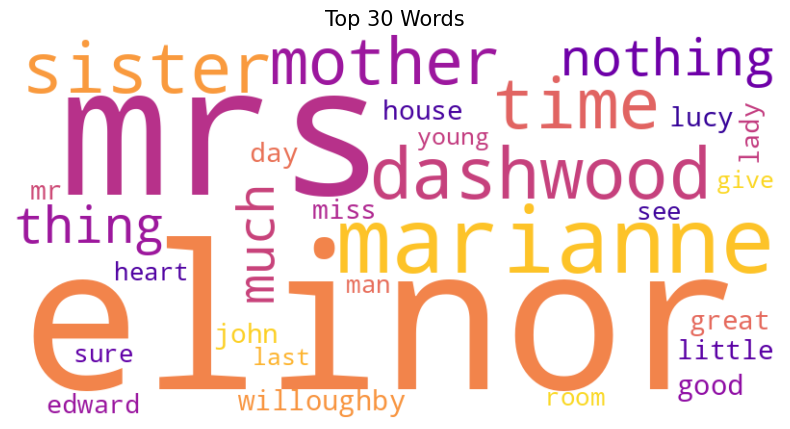

In [27]:
# Top 30 단어 딕셔너리를 기반으로 워드 클라우드 생성
wc_top30 = WordCloud(width=800, height=400, 
                     background_color='white', 
                     colormap='plasma').generate_from_frequencies(top30_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wc_top30, interpolation='bilinear')
plt.title('Top 30 Words', fontsize=15)
plt.axis('off')
plt.show()